# Prediccion de Admision Universitaria con Regresion Logistica

---

**Autor:** Borja Mora Mendez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoria:** Machine Learning · Supervisado · Clasificacion · Regresion Logistica

---

### Objetivo

Construir un modelo de **Regresion Logistica** para predecir la admision universitaria a partir de horas de estudio y nota de examen. Con solo 2 features, podemos **visualizar la frontera de decision** — algo imposible en problemas con mas variables. Este notebook complementa el [caso del gimnasio](../01-gimnasio/) ofreciendo una perspectiva geometrica de como la regresion logistica separa las clases.

### Por que este dataset

- **2 variables:** permite graficar la frontera de decision en 2D
- **1.140 registros:** suficiente masa critica para resultados fiables
- **Desbalanceo 77/23:** exige atencion al threshold y metricas mas alla de accuracy

## 1. Contexto de negocio

**El cliente:** departamento de admisiones de una universidad.

**El problema:** cada ciclo de admisiones llegan miles de solicitudes. El departamento quiere un sistema de scoring que estime la probabilidad de admision basandose en el expediente academico (horas de preparacion y nota de examen de acceso).

**El valor:** automatizar el primer filtro de admisiones ahorra semanas de revision manual y reduce el sesgo subjetivo.

## 2. Stack tecnico

| Libreria | Uso |
|---|---|
| `pandas` | Manipulacion de datos |
| `matplotlib`, `seaborn` | Visualizacion |
| `scikit-learn` | LogisticRegression, metricas |
| `statsmodels` | Modelo Logit con p-valores y odds ratios |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
)
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

## 3. Carga y exploracion inicial

| Variable | Tipo | Descripcion |
|---|---|---|
| `Horas_estudio` | Numerica | Horas de estudio semanales (0-30) |
| `Nota_examen` | Numerica | Nota del examen de acceso (35-103) |
| `Admitido` | Binaria (target) | 1 = admitido, 0 = no admitido |

In [2]:
data = pd.read_excel("admitidos.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head(10)

Registros: 1140 | Columnas: 3


,Horas_estudio,Nota_examen,Admitido
0,3,43.185412,0
1,7,50.346164,0
2,29,99.396287,1
3,13,68.363516,0
4,1,44.349536,0
5,20,77.713132,1
6,1,41.990022,0
7,2,45.948137,0
8,2,44.556393,0
9,1,42.297107,0


In [3]:
data.describe().round(2)

,Horas_estudio,Nota_examen,Admitido
count,1140.00,1140.00,1140.00
mean,9.98,59.93,0.23
std,8.93,18.03,0.42
min,0.00,35.14,0.00
25%,2.00,44.51,0.00
50%,7.00,55.35,0.00
75%,17.00,73.80,0.00
max,30.00,102.98,1.00


In [4]:
balance = data["Admitido"].value_counts(normalize=True)
print("Distribucion del target (Admitido):")
print(f"  No admitido (0): {balance[0]:.1%}")
print(f"  Admitido (1):    {balance[1]:.1%}")
print()
print("Dataset DESBALANCEADO (~77/23). Implicaciones:")
print("  - Un modelo que siempre diga 0 acertaria el 77%")
print("  - Precision y Recall son mas informativas que accuracy")
print("  - El threshold optimo probablemente difiera de 0.5")

Distribucion del target (Admitido):
  No admitido (0): 76.8%
  Admitido (1):    23.2%

Dataset DESBALANCEADO (~77/23). Implicaciones:
  - Un modelo que siempre diga 0 acertaria el 77%
  - Precision y Recall son mas informativas que accuracy
  - El threshold optimo probablemente difiera de 0.5


## 4. Analisis exploratorio

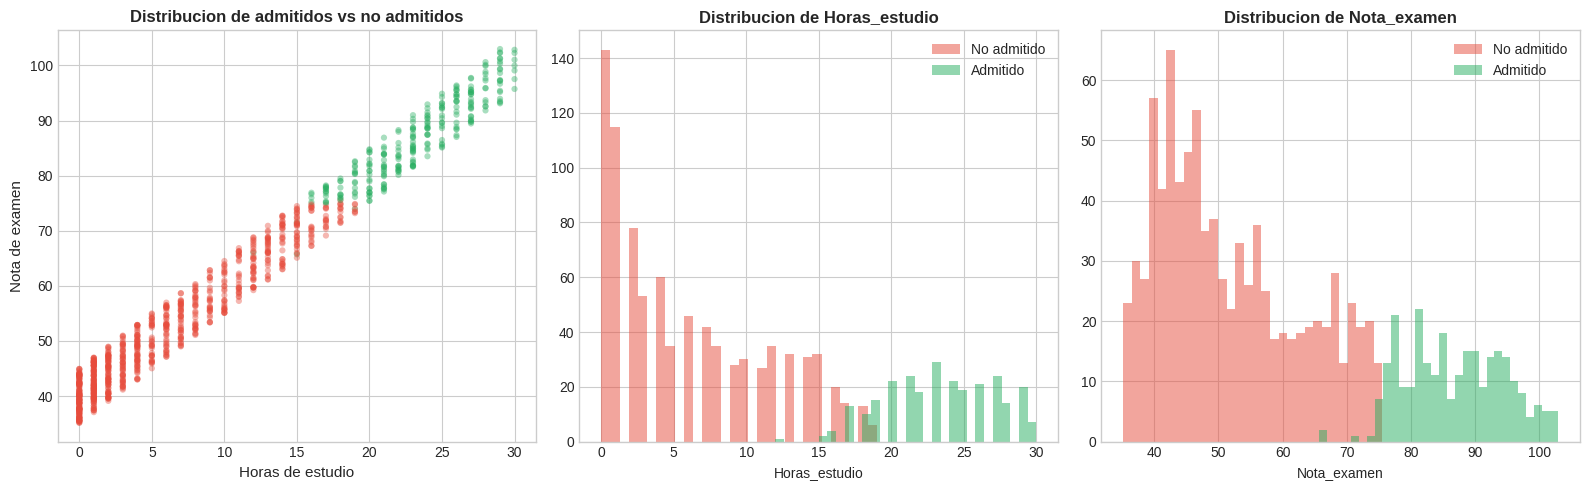

Correlaciones con Admitido:
Horas_estudio    0.8224
Nota_examen      0.8210


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Scatter coloreado por clase
colors = data["Admitido"].map({0: "#e74c3c", 1: "#27ae60"})
axes[0].scatter(data["Horas_estudio"], data["Nota_examen"],
                c=colors, alpha=0.4, edgecolors="none", s=20)
axes[0].set_xlabel("Horas de estudio", fontsize=11)
axes[0].set_ylabel("Nota de examen", fontsize=11)
axes[0].set_title("Distribucion de admitidos vs no admitidos", fontsize=12, fontweight="bold")

# Distribuciones por clase
for i, feat in enumerate(["Horas_estudio", "Nota_examen"]):
    for label, color, name in [(0, "#e74c3c", "No admitido"), (1, "#27ae60", "Admitido")]:
        subset = data[data["Admitido"] == label][feat]
        axes[i+1].hist(subset, bins=30, alpha=0.5, color=color, label=name)
    axes[i+1].set_title(f"Distribucion de {feat}", fontsize=12, fontweight="bold")
    axes[i+1].legend()
    axes[i+1].set_xlabel(feat)

plt.tight_layout()
plt.show()

corr = data.corr()["Admitido"].drop("Admitido")
print("Correlaciones con Admitido:")
print(corr.round(4).to_string())

### Lectura

En el scatter ya se intuye una zona donde se concentran los admitidos (esquina superior derecha: muchas horas + nota alta). Ambas variables correlacionan positivamente con la admision. La regresion logistica encontrara la linea que mejor separa las dos nubes.

## 5. Preparacion de datos

In [6]:
X = data[["Horas_estudio", "Nota_examen"]]
y = data["Admitido"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} admitidos)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} admitidos)")

Train: 855 registros (23.3% admitidos)
Test:  285 registros (23.2% admitidos)


## 6. Modelo estadistico — `statsmodels.Logit`

Primero statsmodels para p-valores, luego sklearn para prediccion y frontera.

In [7]:
X_train_sm = sm.add_constant(X_train).astype(float)
X_test_sm = sm.add_constant(X_test).astype(float)

modelo_logit = sm.Logit(y_train, X_train_sm).fit(disp=0)
print(modelo_logit.summary())

                           Logit Regression Results                           
Dep. Variable:               Admitido   No. Observations:                  855
Model:                          Logit   Df Residuals:                      852
Method:                           MLE   Df Model:                            2
Date:                Mon, 27 Jul 2026   Pseudo R-squ.:                  0.9205
Time:                        11:55:24   Log-Likelihood:                -36.889
converged:                       True   LL-Null:                       -463.90
Covariance Type:            nonrobust   LLR p-value:                3.553e-186
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const           -60.8436     11.935     -5.098      0.000     -84.237     -37.451
Horas_estudio     0.2127      0.208      1.022      0.307      -0.195       0.621
Nota_examen       0.7586      0.180     

### 6.1 Odds Ratios

In [8]:
coefs = modelo_logit.params
conf = modelo_logit.conf_int()
conf.columns = ["IC 2.5%", "IC 97.5%"]

tabla_or = pd.DataFrame({
    "Coeficiente": coefs,
    "Odds Ratio": np.exp(coefs),
    "IC 2.5%": np.exp(conf["IC 2.5%"]),
    "IC 97.5%": np.exp(conf["IC 97.5%"]),
    "P-valor": modelo_logit.pvalues,
}).round(4)

print("Odds Ratios con intervalos de confianza:")
print(tabla_or.to_string())
print()
for var in ["Horas_estudio", "Nota_examen"]:
    or_val = tabla_or.loc[var, "Odds Ratio"]
    if or_val > 1:
        pct = (or_val - 1) * 100
        print(f"  {var}: cada unidad adicional AUMENTA las odds de admision un {pct:.1f}%")
    else:
        pct = (1 - or_val) * 100
        print(f"  {var}: cada unidad adicional REDUCE las odds de admision un {pct:.1f}%")

Odds Ratios con intervalos de confianza:
               Coeficiente  Odds Ratio  IC 2.5%  IC 97.5%  P-valor
const             -60.8436      0.0000   0.0000    0.0000   0.0000
Horas_estudio       0.2127      1.2370   0.8226    1.8601   0.3069
Nota_examen         0.7586      2.1353   1.5011    3.0373   0.0000

  Horas_estudio: cada unidad adicional AUMENTA las odds de admision un 23.7%
  Nota_examen: cada unidad adicional AUMENTA las odds de admision un 113.5%


## 7. Modelo de produccion — `sklearn.LogisticRegression`

In [9]:
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print("Regresion Logistica — Metricas (threshold=0.5)")
print(f"Accuracy:  {acc:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"AUC-ROC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No admitido", "Admitido"]))

Regresion Logistica — Metricas (threshold=0.5)
Accuracy:  99.3%
Recall:    97.0%
AUC-ROC:   0.999

              precision    recall  f1-score   support

 No admitido       0.99      1.00      1.00       219
    Admitido       1.00      0.97      0.98        66

    accuracy                           0.99       285
   macro avg       1.00      0.98      0.99       285
weighted avg       0.99      0.99      0.99       285



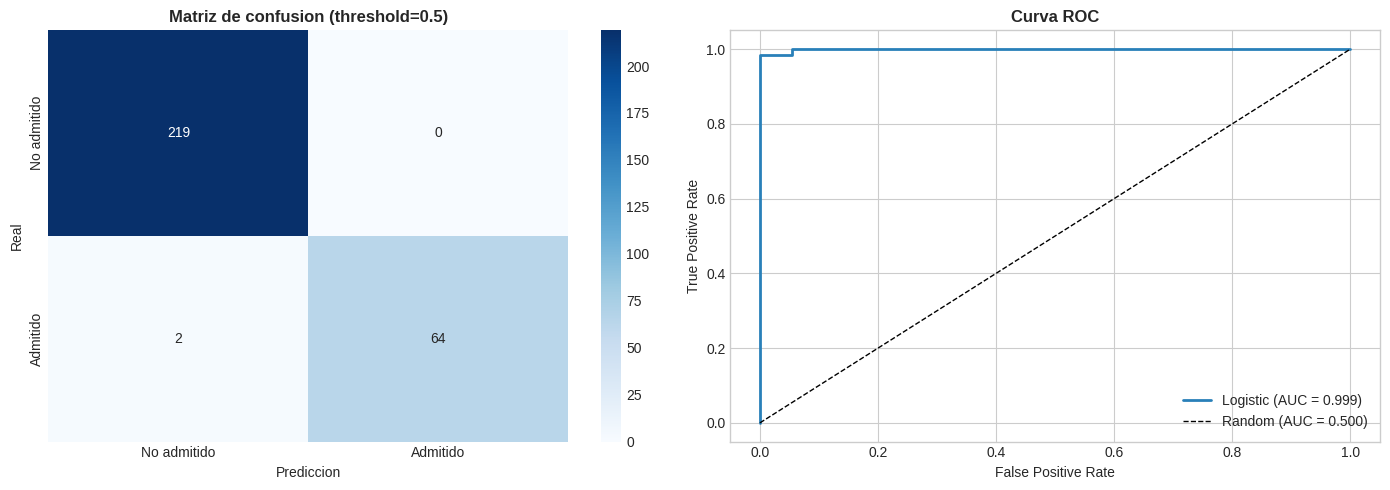

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No admitido", "Admitido"],
            yticklabels=["No admitido", "Admitido"], ax=axes[0])
axes[0].set_title("Matriz de confusion (threshold=0.5)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Prediccion")
axes[0].set_ylabel("Real")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color="#2980b9", linewidth=2, label=f"Logistic (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], "k--", linewidth=1, label="Random (AUC = 0.500)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

## 8. Frontera de decision — la ventaja de 2 variables

Esta es la visualizacion estrella del notebook: con solo 2 features podemos graficar exactamente **donde el modelo cambia de prediccion**. La linea que separa la zona verde (admitido) de la roja (no admitido) es la frontera de decision. Cada punto es un estudiante real del test set.

/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/sessions/zen-stoic-carson/tmp/ipykernel_4/1564976892.py:20: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X_test.loc[mask, "Horas_estudio"],


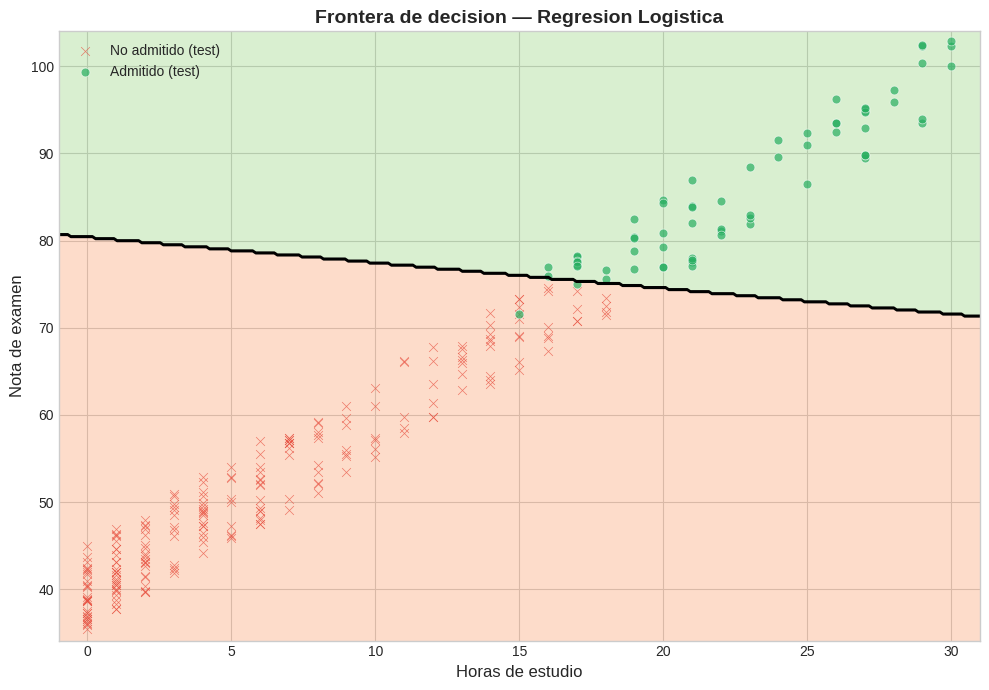

Ecuacion de la frontera de decision (p=0.5):
  -59.5191 + 0.2173 * Horas_estudio + 0.7398 * Nota_examen = 0
  Nota_examen = 80.45 - 0.2938 * Horas_estudio


In [11]:
# Crear malla para la frontera de decision
x_min, x_max = X["Horas_estudio"].min() - 1, X["Horas_estudio"].max() + 1
y_min, y_max = X["Nota_examen"].min() - 1, X["Nota_examen"].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                      np.linspace(y_min, y_max, 300))

Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))

# Regiones de decision
ax.contourf(xx, yy, Z, alpha=0.3, cmap="RdYlGn", levels=1)
ax.contour(xx, yy, Z, colors="black", linewidths=1.5, levels=1)

# Puntos del test set
for label, color, marker, name in [(0, "#e74c3c", "x", "No admitido"),
                                    (1, "#27ae60", "o", "Admitido")]:
    mask = y_test == label
    ax.scatter(X_test.loc[mask, "Horas_estudio"],
               X_test.loc[mask, "Nota_examen"],
               c=color, marker=marker, s=40, alpha=0.7,
               edgecolors="white" if label == 1 else "none",
               linewidths=0.5, label=f"{name} (test)")

ax.set_xlabel("Horas de estudio", fontsize=12)
ax.set_ylabel("Nota de examen", fontsize=12)
ax.set_title("Frontera de decision — Regresion Logistica", fontsize=14, fontweight="bold")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Ecuacion de la frontera
b0 = model.intercept_[0]
b1, b2 = model.coef_[0]
print("Ecuacion de la frontera de decision (p=0.5):")
print(f"  {b0:.4f} + {b1:.4f} * Horas_estudio + {b2:.4f} * Nota_examen = 0")
print(f"  Nota_examen = {-b0/b2:.2f} - {b1/b2:.4f} * Horas_estudio")

/sessions/zen-stoic-carson/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


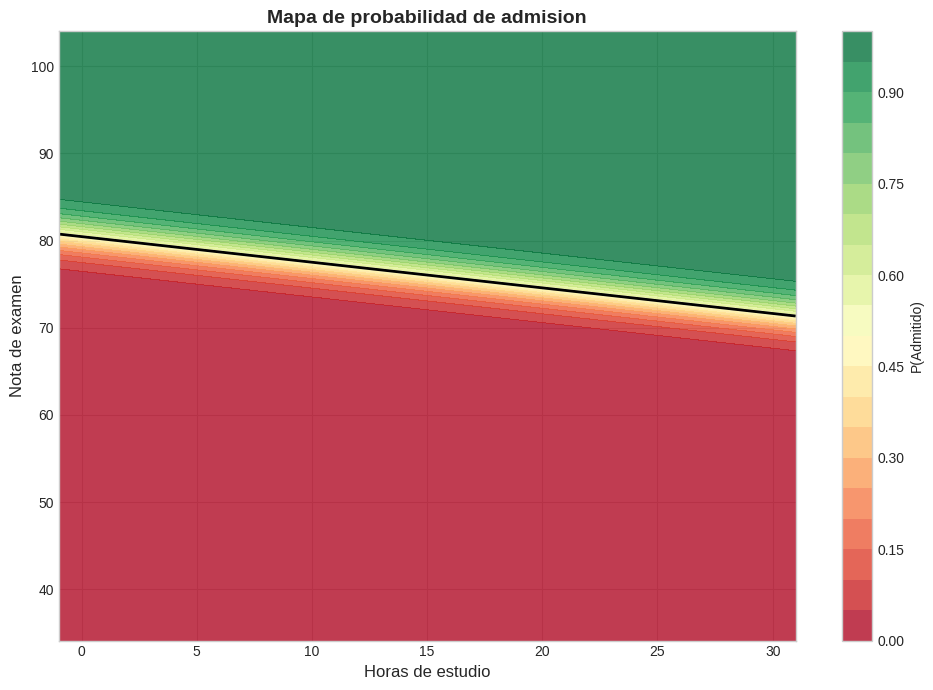

El mapa muestra un gradiente suave de probabilidad.
La linea negra marca p=0.5 (frontera de decision por defecto).
Ajustar el threshold mueve esta linea a la izquierda (mas permisivo) o derecha (mas estricto).


In [12]:
# Mapa de probabilidad continua
Z_prob = model.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1]
Z_prob = Z_prob.reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
contour = ax.contourf(xx, yy, Z_prob, levels=20, cmap="RdYlGn", alpha=0.8)
plt.colorbar(contour, ax=ax, label="P(Admitido)")

# Contorno de p=0.5
ax.contour(xx, yy, Z_prob, levels=[0.5], colors="black", linewidths=2)

ax.set_xlabel("Horas de estudio", fontsize=12)
ax.set_ylabel("Nota de examen", fontsize=12)
ax.set_title("Mapa de probabilidad de admision", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("El mapa muestra un gradiente suave de probabilidad.")
print("La linea negra marca p=0.5 (frontera de decision por defecto).")
print("Ajustar el threshold mueve esta linea a la izquierda (mas permisivo) o derecha (mas estricto).")

## 9. Analisis de threshold

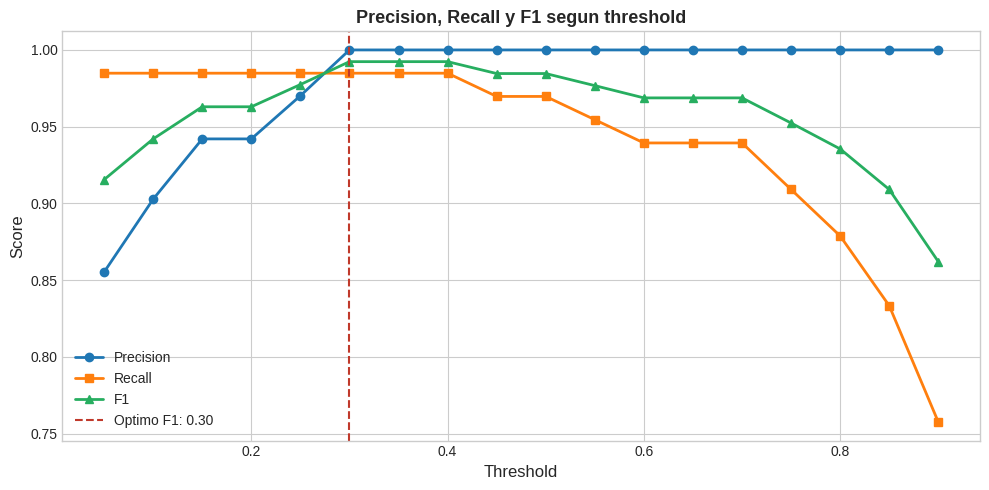

Threshold optimo (max F1): 0.30
  Precision: 100.0%
  Recall:    98.5%
  F1:        99.2%


In [13]:
thresholds = np.arange(0.05, 0.95, 0.05)
results = []

for th in thresholds:
    y_th = (y_prob >= th).astype(int)
    results.append({
        "Threshold": th,
        "Precision": precision_score(y_test, y_th, zero_division=0),
        "Recall": recall_score(y_test, y_th, zero_division=0),
        "F1": f1_score(y_test, y_th, zero_division=0),
    })

df_th = pd.DataFrame(results)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(df_th["Threshold"], df_th["Precision"], marker="o", label="Precision", linewidth=2)
ax.plot(df_th["Threshold"], df_th["Recall"], marker="s", label="Recall", linewidth=2)
ax.plot(df_th["Threshold"], df_th["F1"], marker="^", label="F1", linewidth=2, color="#27ae60")

th_optimo = df_th.loc[df_th["F1"].idxmax(), "Threshold"]
ax.axvline(x=th_optimo, color="#c0392b", linestyle="--", linewidth=1.5, label=f"Optimo F1: {th_optimo:.2f}")

ax.set_xlabel("Threshold", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Precision, Recall y F1 segun threshold", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Threshold optimo (max F1): {th_optimo:.2f}")
y_opt = (y_prob >= th_optimo).astype(int)
print(f"  Precision: {precision_score(y_test, y_opt):.1%}")
print(f"  Recall:    {recall_score(y_test, y_opt):.1%}")
print(f"  F1:        {f1_score(y_test, y_opt):.1%}")

## 10. Insights de negocio y recomendaciones

### El hallazgo

> La frontera de decision revela que la admision depende de una **combinacion lineal** de horas de estudio y nota de examen. No es solo la nota, ni solo las horas — es una compensacion: un estudiante con menos horas puede ser admitido si su nota compensa, y viceversa.

### Recomendaciones

**1. Sistema de scoring automatizado (impacto: alto)**
La probabilidad continua del modelo permite rankear solicitudes, no solo clasificarlas. El departamento de admisiones puede establecer cortes (>70% = admision directa, 30-70% = revision manual, <30% = rechazo) para optimizar el tiempo de revision.

**2. Transparencia con los candidatos (impacto: medio)**
Con solo 2 variables, la frontera de decision es explicable a los propios candidatos: *"necesitas una combinacion de horas y nota que supere este umbral"*. Esto reduce disputas y aumenta la confianza en el proceso.

**3. El valor pedagogico de 2D (impacto: portfolio)**
Este notebook demuestra una habilidad que muchos candidatos a Data Analyst no muestran: **visualizar como piensa un modelo**. La frontera de decision y el mapa de probabilidad son herramientas de comunicacion, no solo de analisis.

## 11. Limitaciones y proximos pasos

**Limitaciones:**
- Solo 2 variables predictoras — en un sistema real se incluirian expediente completo, actividades extracurriculares, cartas de recomendacion.
- La frontera es lineal (propiedad de la regresion logistica); un SVM con kernel o un arbol podrian capturar fronteras no lineales.
- Desbalanceo 77/23 no es extremo, pero un SMOTE o class_weight="balanced" podria mejorar el recall.

**Proximos pasos:**
- [ ] Comparar con la [regresion logistica del gimnasio](../01-gimnasio/) que tiene 4 features y usa VIF/multicolinealidad.
- [ ] Explorar los notebooks de [arboles de decision](../../01-arbol-decision/) y [comparativa de modelos](../../04-comparativa-modelos/) para ver fronteras no lineales sobre el dataset del gimnasio.